# 10 — Health Benefit Curves B(d)

Visualises and calibrates the health benefit function B(d) for each demographic group.

## What B(d) represents

B(d) is the modelled health benefit of walking distance d metres to a transit stop.
It is a Gaussian bell curve:

- Near zero at d = 0 (a stop at your door generates almost no walking)
- Peaks at d = mu (the optimal walking distance for this demographic group)
- Decays symmetrically; zeroed beyond d_max

## Literature anchors

No existing paper provides a ready-made B(d) curve for transit stop placement.
Parameters are calibrated against:

| Reference                          | Key finding                                                                                                 | Role in calibration                                            |
| ---------------------------------- | ----------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------- |
| Besser & Dannenberg (2005)         | 85th-percentile walk to bus ≈ 524m; median daily transit walking = 19 min                                   | Sets upper bound on working-age d_max                          |
| Samitz et al. (2011) meta-analysis | Largest mortality gains at moderate activity (7.5 MET-h/wk, HR=0.80); diminishing returns above 15 MET-h/wk | Motivates non-linear shape — small walks near-zero, not linear |
| WHO GAPPA (2018)                   | 10-minute walk (≈800m at 1.4 m/s) as guideline minimum                                                      | Informs d_max for working-age group                            |
| Andersen et al. (2000)             | Cycling to work: HR=0.72; dose-response across activity levels                                              | Confirms benefit is real and non-trivial for Danish population |

**B(d) is our synthesised model.** Parameter choices should be stated as assumptions
in the tool UI and any published output.

## This notebook

- Plot all 3 demographic curves on the same axes at 20m resolution
- Interactive parameter adjustment via widgets (or manual cell edits)
- Annotate reference markers from the literature
- No network code — this is pure B(d) exploration


In [1]:
import sys
from pathlib import Path

project_root = Path("..").resolve()
sys.path.insert(0, str(project_root))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from src.health.benefit_curves import B, B_group, distance_axis, DEMOGRAPHIC_PARAMS

print("Benefit curves module loaded")
print(f"Demographic groups: {list(DEMOGRAPHIC_PARAMS.keys())}")

Benefit curves module loaded
Demographic groups: ['working_age', 'elderly', 'children']


## 1. Plot Default Curves

All three demographic groups on one chart at 20m resolution.


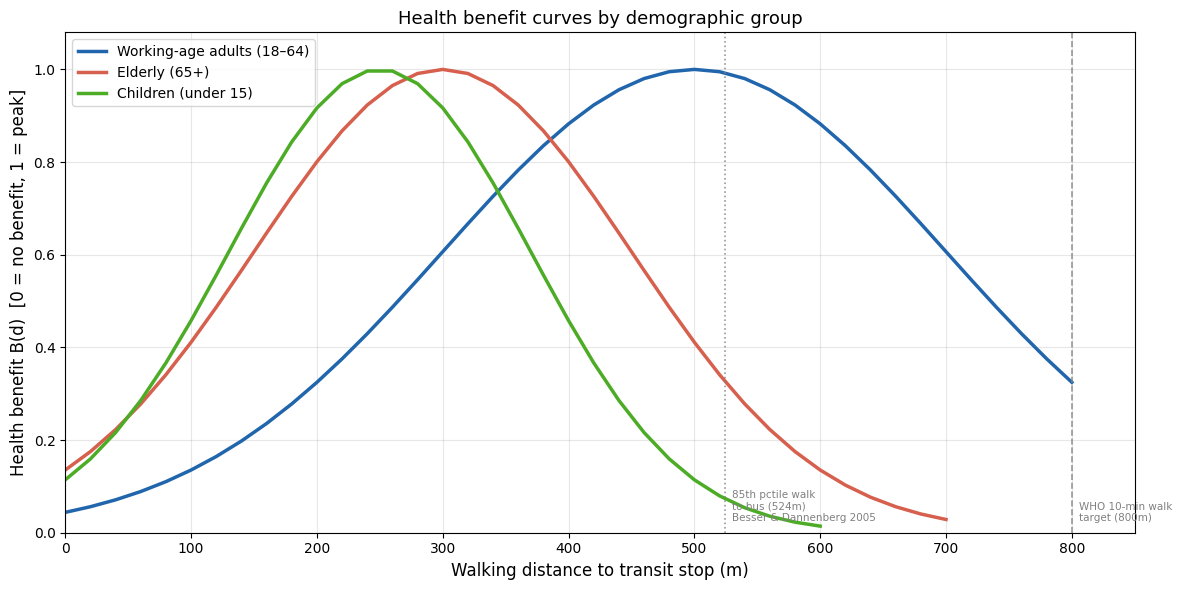


Parameter summary:
  working_age: mu=500m  sigma=200m  d_max=800m
  elderly: mu=300m  sigma=150m  d_max=700m
  children: mu=250m  sigma=120m  d_max=600m


In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

for group, params in DEMOGRAPHIC_PARAMS.items():
    d = distance_axis(d_max=params["d_max"], step=20)
    b = B(d, mu=params["mu"], sigma=params["sigma"], d_max=params["d_max"])
    ax.plot(d, b, label=params["label"], color=params["color"], linewidth=2.5)

# Literature reference markers
ax.axvline(524, color="gray", linestyle=":", linewidth=1.2, alpha=0.8)
ax.text(
    530,
    0.02,
    "85th pctile walk\nto bus (524m)\nBesser & Dannenberg 2005",
    fontsize=7.5,
    color="gray",
    va="bottom",
)

ax.axvline(800, color="gray", linestyle="--", linewidth=1.2, alpha=0.8)
ax.text(
    806, 0.02, "WHO 10-min walk\ntarget (800m)", fontsize=7.5, color="gray", va="bottom"
)

ax.set_xlabel("Walking distance to transit stop (m)", fontsize=12)
ax.set_ylabel("Health benefit B(d)  [0 = no benefit, 1 = peak]", fontsize=12)
ax.set_title("Health benefit curves by demographic group", fontsize=13)
ax.set_xlim(0, 850)
ax.set_ylim(0, 1.08)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nParameter summary:")
for group, params in DEMOGRAPHIC_PARAMS.items():
    print(
        f"  {group}: mu={params['mu']}m  sigma={params['sigma']}m  d_max={params['d_max']}m"
    )

## 2. Tune Parameters

Edit the values below and re-run the cell to explore different curve shapes.
The key questions:

- Does the **peak** (mu) reflect realistic optimal walking distance for each group?
- Is the **width** (sigma) wide or narrow enough?
  - Small sigma → sharp peak, only a narrow distance range benefits
  - Large sigma → flat plateau, many distances are roughly equivalent
- Does d_max correctly cut off benefit at the deterrence threshold?

**Working-age**: literature suggests 400–700m optimal; 524m is the empirical 85th percentile.
**Elderly**: deterrence rises sharply beyond 400–500m; peak should be closer to 300m.
**Children**: habit-formation and safety dominate; shorter distances, tighter curve.


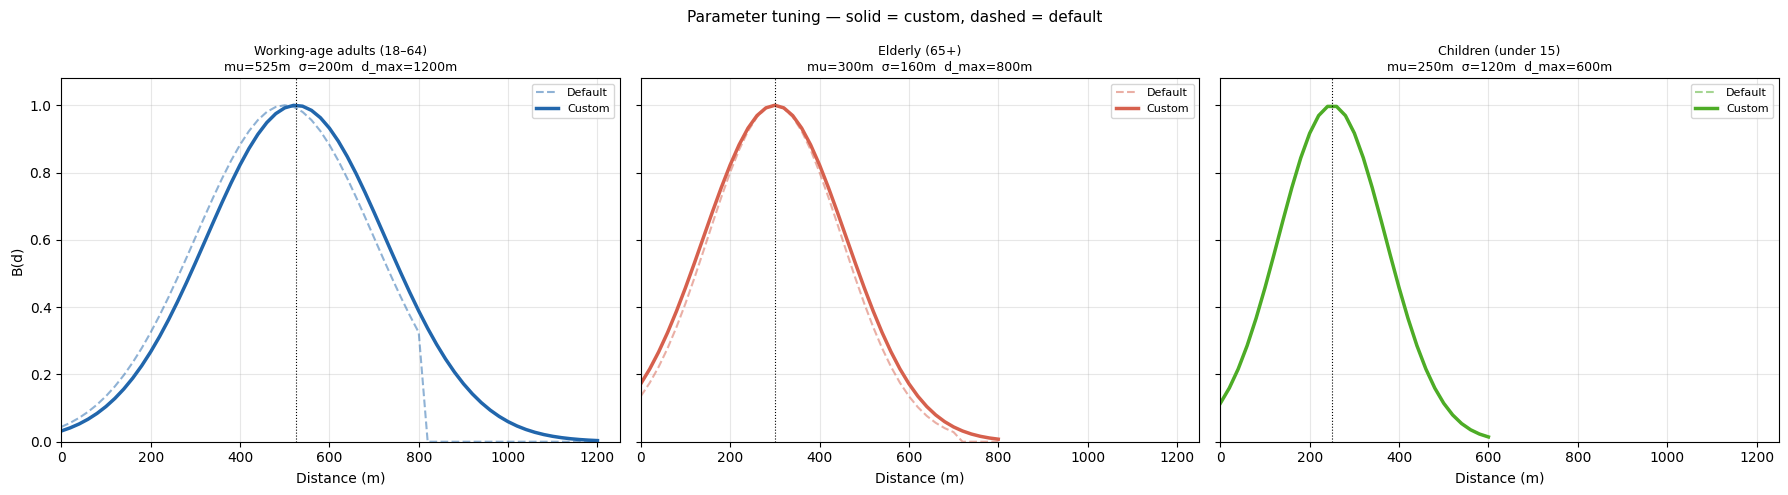

In [ ]:
# ── Adjust parameters here ──────────────────────────────────────────────────
custom_params = {
    "working_age": {"mu": 525, "sigma": 200, "d_max": 1200},
    "elderly": {"mu": 300, "sigma": 160, "d_max": 800},
    "children": {"mu": 250, "sigma": 120, "d_max": 600},
}
# ────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (group, p) in zip(axes, custom_params.items()):
    defaults = DEMOGRAPHIC_PARAMS[group]
    d = distance_axis(d_max=max(p["d_max"], defaults["d_max"]), step=20)

    # Default curve (dashed)
    b_default = B(
        d, mu=defaults["mu"], sigma=defaults["sigma"], d_max=defaults["d_max"]
    )
    ax.plot(
        d,
        b_default,
        color=defaults["color"],
        linewidth=1.5,
        linestyle="--",
        alpha=0.5,
        label="Default",
    )

    # Custom curve (solid)
    b_custom = B(d, mu=p["mu"], sigma=p["sigma"], d_max=p["d_max"])
    ax.plot(d, b_custom, color=defaults["color"], linewidth=2.5, label="Custom")

    ax.axvline(p["mu"], color="black", linewidth=0.8, linestyle=":")
    ax.set_title(
        f"{defaults['label']}\nmu={p['mu']}m  σ={p['sigma']}m  d_max={p['d_max']}m",
        fontsize=9,
    )
    ax.set_xlabel("Distance (m)")
    ax.set_xlim(0, 1250)
    ax.set_ylim(0, 1.08)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

axes[0].set_ylabel("B(d)")
plt.suptitle("Parameter tuning — solid = custom, dashed = default", fontsize=11)
plt.tight_layout()
plt.show()

## 3. Inspect B(d) Values at Key Distances

Check what benefit weight is assigned at specific distances.
This helps verify that the curves encode the right intuitions before scoring.


In [13]:
check_distances = [50, 100, 200, 300, 400, 500, 600, 700, 800]

print(f"{'Distance':>10}  ", end="")
for group in DEMOGRAPHIC_PARAMS:
    print(f"{group:>16}", end="")
print()
print("-" * (10 + 2 + 16 * len(DEMOGRAPHIC_PARAMS)))

for d in check_distances:
    print(f"{d:>9}m  ", end="")
    for group, params in DEMOGRAPHIC_PARAMS.items():
        val = B(d, mu=params["mu"], sigma=params["sigma"], d_max=params["d_max"])
        print(f"{float(val):>16.3f}", end="")
    print()

  Distance       working_age         elderly        children
------------------------------------------------------------
       50m             0.080           0.249           0.249
      100m             0.135           0.411           0.458
      200m             0.325           0.801           0.917
      300m             0.607           1.000           0.917
      400m             0.882           0.801           0.458
      500m             1.000           0.411           0.114
      600m             0.882           0.135           0.014
      700m             0.607           0.029           0.000
      800m             0.325           0.000           0.000


## 4. B(d) at the Besser & Dannenberg Empirical Reference Points

What benefit do the current curves assign at the empirically observed walking distances?
These are reality checks — if B(524m) is near zero for working-age adults, the curve is
misaligned with observed behaviour.


In [14]:
# Empirical reference distances from literature
refs = {
    "85th pctile to bus (Besser & Dannenberg 2005)": 524,
    "Median transit walk (Besser & Dannenberg 2005, ~19 min ÷ 2 trips)": 800,
    "Traditional planning threshold — bus": 400,
    "Traditional planning threshold — rail": 800,
}

for ref_label, ref_d in refs.items():
    print(f"\n{ref_label} — d = {ref_d}m")
    for group, params in DEMOGRAPHIC_PARAMS.items():
        val = B(ref_d, mu=params["mu"], sigma=params["sigma"], d_max=params["d_max"])
        bar = "█" * int(val * 20)
        print(f"  {group:>15}: {val:.3f}  {bar}")


85th pctile to bus (Besser & Dannenberg 2005) — d = 524m
      working_age: 0.993  ███████████████████
          elderly: 0.328  ██████
         children: 0.074  █

Median transit walk (Besser & Dannenberg 2005, ~19 min ÷ 2 trips) — d = 800m
      working_age: 0.325  ██████
          elderly: 0.000  
         children: 0.000  

Traditional planning threshold — bus — d = 400m
      working_age: 0.882  █████████████████
          elderly: 0.801  ████████████████
         children: 0.458  █████████

Traditional planning threshold — rail — d = 800m
      working_age: 0.325  ██████
          elderly: 0.000  
         children: 0.000  
